<h2 style="text-align: center;">Predicting Camptothecin Drug Resistance with Supervised Machine Learning</h2>
<h3 style="text-align: center;">Model Development, Tuning, and Evaluation</h3>
<h4 style="text-align: center;">Dr. Quincy Snell</h4>

**Source:** GDSC (Genomics of Drug Sensitivity in Cancer) Database – https://www.cancerrxgene.org/

**Description:** "This dataset is derived from the Genomics of Drug Sensitivity in Cancer (GDSC) project, which aims to identify molecular features of cancers that predict response to anti-cancer drugs. The dataset focuses on Camptothecin (a TOP1 inhibitor used in cancer treatment) and includes drug sensitivity measurements across diverse cancer cell lines, along with molecular and clinical descriptors."

**Variables (n=11, after feature selection):**
- AUC (target: area under the drug response curve)
- TCGA_DESC (cancer type descriptor, 32 categories)
- GDSC_Tissue_descriptor_1 (tissue descriptor, 19 categories)
- Cancer_Type (TCGA cancer type label, 31 categories)
- MSI (microsatellite instability status)
- Screen_Medium (screening medium type)
- Growth_Properties (cell growth type: Adherent/Suspension/Semi-Adherent)
- CNA (copy number alteration data availability)
- Gene_Expression (gene expression data availability)
- Methylation (methylation data availability)
- RESISTANT (target variable: 0 = Sensitive, 1 = Resistant)

In [ ]:
# Import core libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Statistical libraries
import scipy.stats as stats
from scipy.stats import skew, norm, probplot, boxcox, f_oneway

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Load dataset (skip if already loaded)
df = pd.read_excel("/content/Cancer_Drug_Dataset.xlsx")

In [ ]:
# Inspect dataset: column names, non-null counts, and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 967 entries, 0 to 966
Data columns (total 19 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   COSMIC_ID                                967 non-null    int64  
 1   CELL_LINE_NAME                           967 non-null    object 
 2   TCGA_DESC                                961 non-null    object 
 3   DRUG_ID                                  967 non-null    int64  
 4   DRUG_NAME                                967 non-null    object 
 5   LN_IC50                                  967 non-null    float64
 6   AUC                                      967 non-null    float64
 7   Z_SCORE                                  967 non-null    float64
 8   GDSC_Tissue_descriptor_1                 928 non-null    object 
 9   GDSC_Tissue_descriptor_2                 928 non-null    object 
 10  Cancer_Type_(matching_TCGA_label)        763 non-n

In [ ]:
# Fix data types (if needed)

# Example conversions:
# df['column_name'] = df['column_name'].astype('category')
# df['column_name'] = df['column_name'].astype('float')
# df['column_name'] = df['column_name'].astype('int')

# Create RESISTANT outcome variable based on median LN_IC50
# (0 = Sensitive, 1 = Resistant)
median_ic50 = df['LN_IC50'].median()
df['RESISTANT'] = (df['LN_IC50'] > median_ic50).astype(int)

# Convert target variable to categorical type
df['RESISTANT'] = df['RESISTANT'].astype('category')

# Rename long column names for readability
df.rename({'Microsatellite_instability_Status_(MSI)': 'MSI'}, axis=1, inplace=True)
df.rename({'Cancer_Type_(matching_TCGA_label)': 'Cancer_Type'}, axis=1, inplace=True)

In [ ]:
# Display the RESISTANT (target) column
df['RESISTANT']

0      1
1      0
2      0
3      0
4      0
      ..
962    1
963    1
964    1
965    1
966    1
Name: RESISTANT, Length: 967, dtype: category
Categories (2, int64): [0, 1]

In [ ]:
# Map target variable values: 0 → 'Sensitive', 1 → 'Resistant'
df['RESISTANT'] = df['RESISTANT'].map({0: 'Sensitive', 1: 'Resistant'})

In [ ]:
# Verify mapping: 0 → 'Sensitive', 1 → 'Resistant'
df['RESISTANT']

0      Resistant
1      Sensitive
2      Sensitive
3      Sensitive
4      Sensitive
         ...    
962    Resistant
963    Resistant
964    Resistant
965    Resistant
966    Resistant
Name: RESISTANT, Length: 967, dtype: category
Categories (2, object): ['Sensitive', 'Resistant']

In [ ]:
# Recode target variable back to numeric values for modeling (Sensitive → 0, Resistant → 1)
df['RESISTANT'] = df['RESISTANT'].map({'Sensitive': 0, 'Resistant': 1})

In [ ]:
# Verify RESISTANT values after recoding
df['RESISTANT']

0      1
1      0
2      0
3      0
4      0
      ..
962    1
963    1
964    1
965    1
966    1
Name: RESISTANT, Length: 967, dtype: category
Categories (2, int64): [0, 1]

In [ ]:
# Verify class distribution after recoding
df['RESISTANT'].value_counts()

RESISTANT
0    484
1    483
Name: count, dtype: int64

## Machine Learning

In [ ]:
# Make copy of the dataset to prevent accidental modification of the original --- look at the first 5 rows to confirm structure, columns, and values
data = df.copy()
data.head()

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC_Tissue_descriptor_1,GDSC_Tissue_descriptor_2,Cancer_Type,MSI,Screen_Medium,Growth_Properties,CNA,Gene_Expression,Methylation,TARGET,TARGET_PATHWAY,RESISTANT
0,683667,PFSK-1,MB,1003,Camptothecin,-1.463887,0.930220,0.433123,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication,1
1,684057,ES5,UNCLASSIFIED,1003,Camptothecin,-3.360586,0.791072,-0.599569,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication,0
2,684059,ES7,UNCLASSIFIED,1003,Camptothecin,-5.044940,0.592660,-1.516647,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication,0
3,684062,EW-11,UNCLASSIFIED,1003,Camptothecin,-3.741991,0.734047,-0.807232,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication,0
4,684072,SK-ES-1,UNCLASSIFIED,1003,Camptothecin,-5.142961,0.582439,-1.570016,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Semi-Adherent,Y,Y,Y,TOP1,DNA replication,0


### Data Preparation

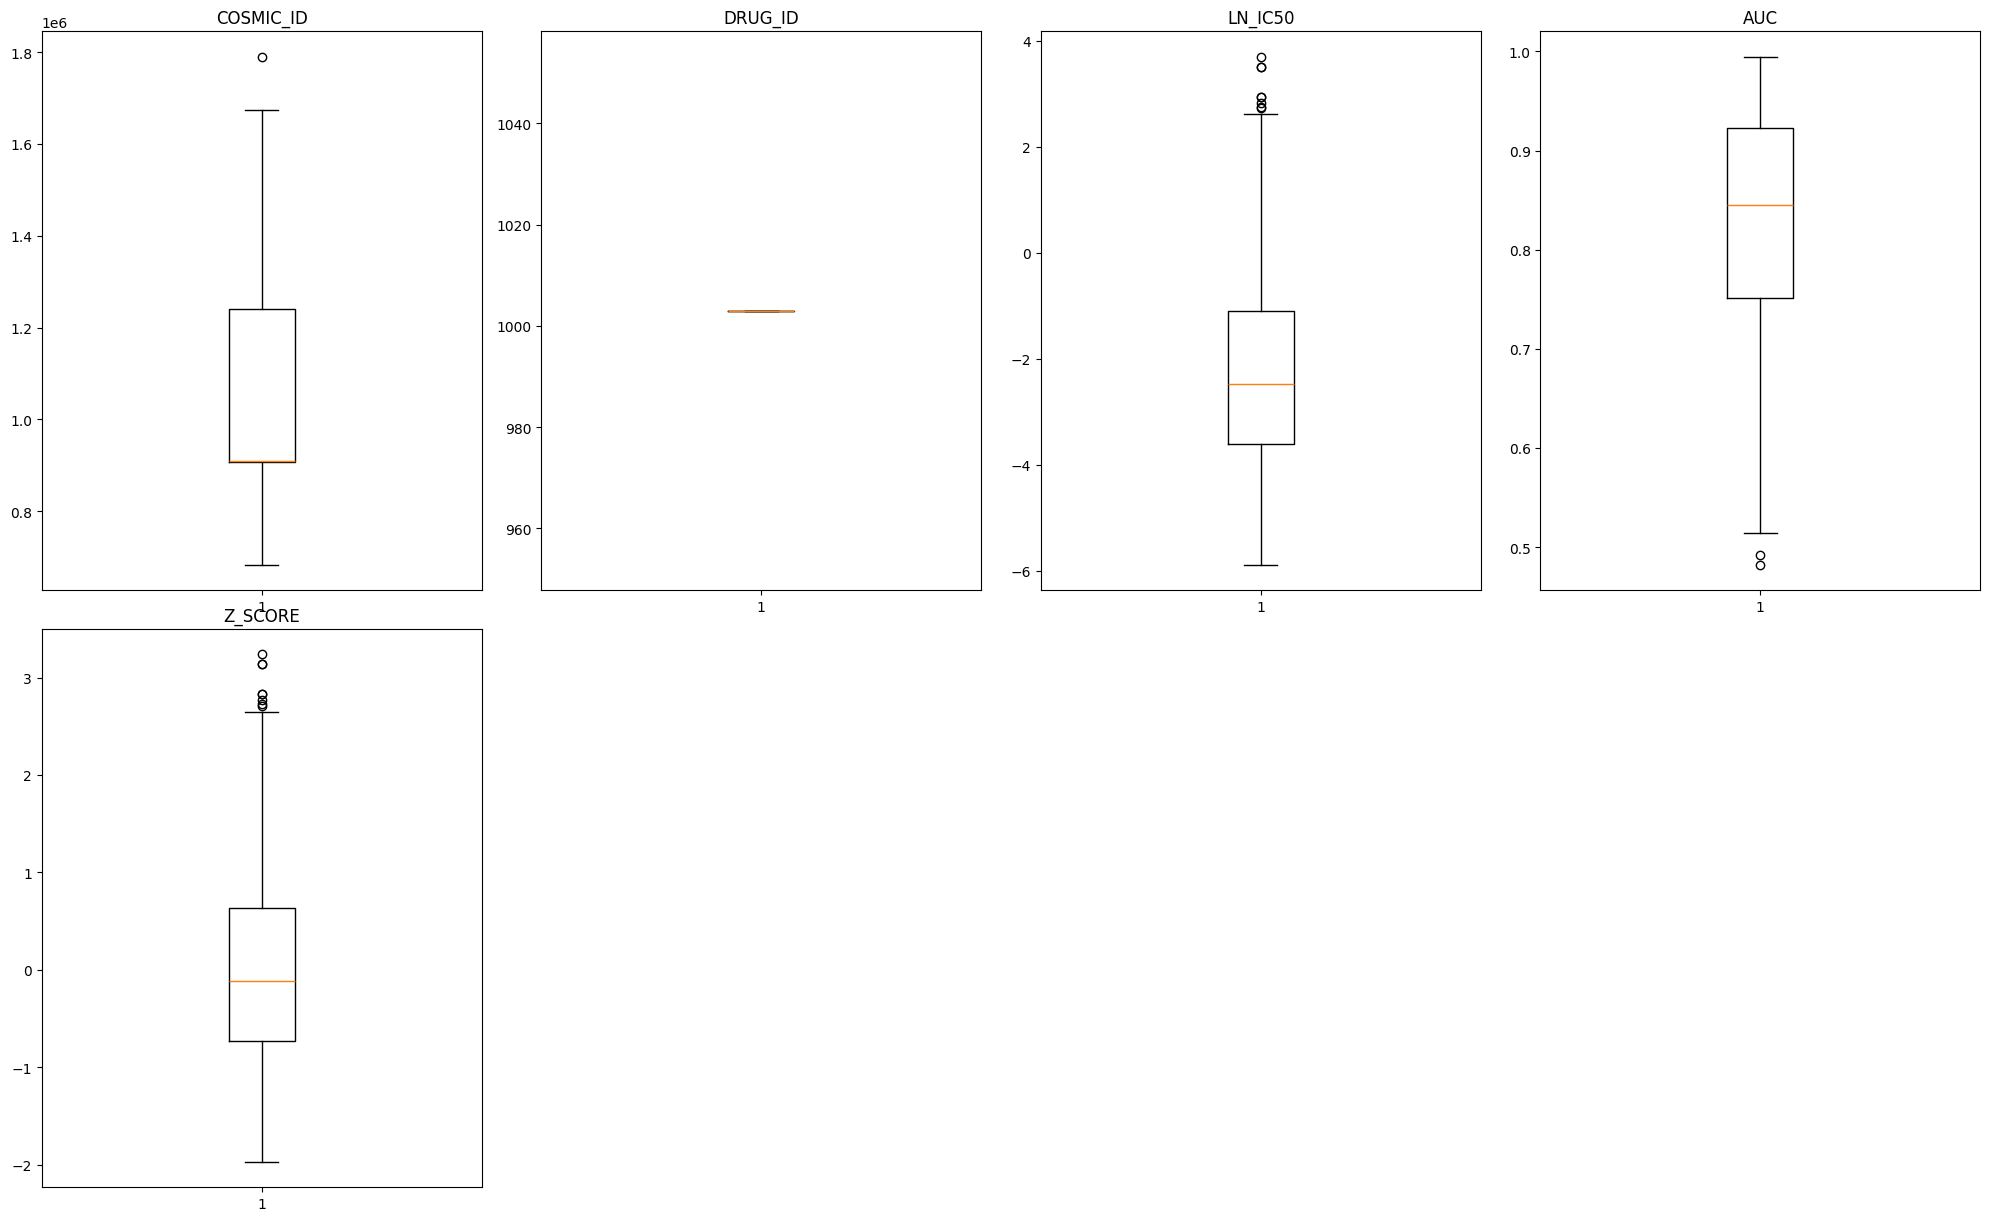

In [ ]:
# Visualize potential outliers across all variables using boxplots

numerical_col = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(20,30))

for i, variable in enumerate(numerical_col):
                     plt.subplot(5,4,i+1)
                     plt.boxplot(data[variable],whis=1.5)
                     plt.tight_layout()
                     plt.title(variable)

plt.show()

### Code to treat outliers

In [ ]:
# Apply flooring and capping (IQR method) to treat outliers
def treat_outliers(data, col):
    """
    Caps outliers in a specified numeric column using the IQR method.

    Parameters:
    data (pd.DataFrame): Input dataframe
    col (str): Name of the numerical column

    Returns:
    pd.DataFrame: DataFrame with outliers capped for the specified column
    """
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_whisker = Q1 - 1.5 * IQR
    upper_whisker = Q3 + 1.5 * IQR

    data[col] = np.clip(data[col], lower_whisker, upper_whisker)

    return data


# Apply outlier treatment to multiple columns
def treat_outliers_all(data, col_list):
    """
    Applies IQR-based outlier capping to a list of numerical columns.

    Parameters:
    data (pd.DataFrame): Input dataframe
    col_list (list): List of numerical column names

    Returns:
    pd.DataFrame: DataFrame with outliers capped for all specified columns
    """
    for col in col_list:
        data = treat_outliers(data, col)
    return data

In [ ]:
# Identify numerical columns and apply IQR-based outlier capping
numerical_col = data.select_dtypes(include=np.number).columns.tolist()
data = treat_outliers_all(data, numerical_col)

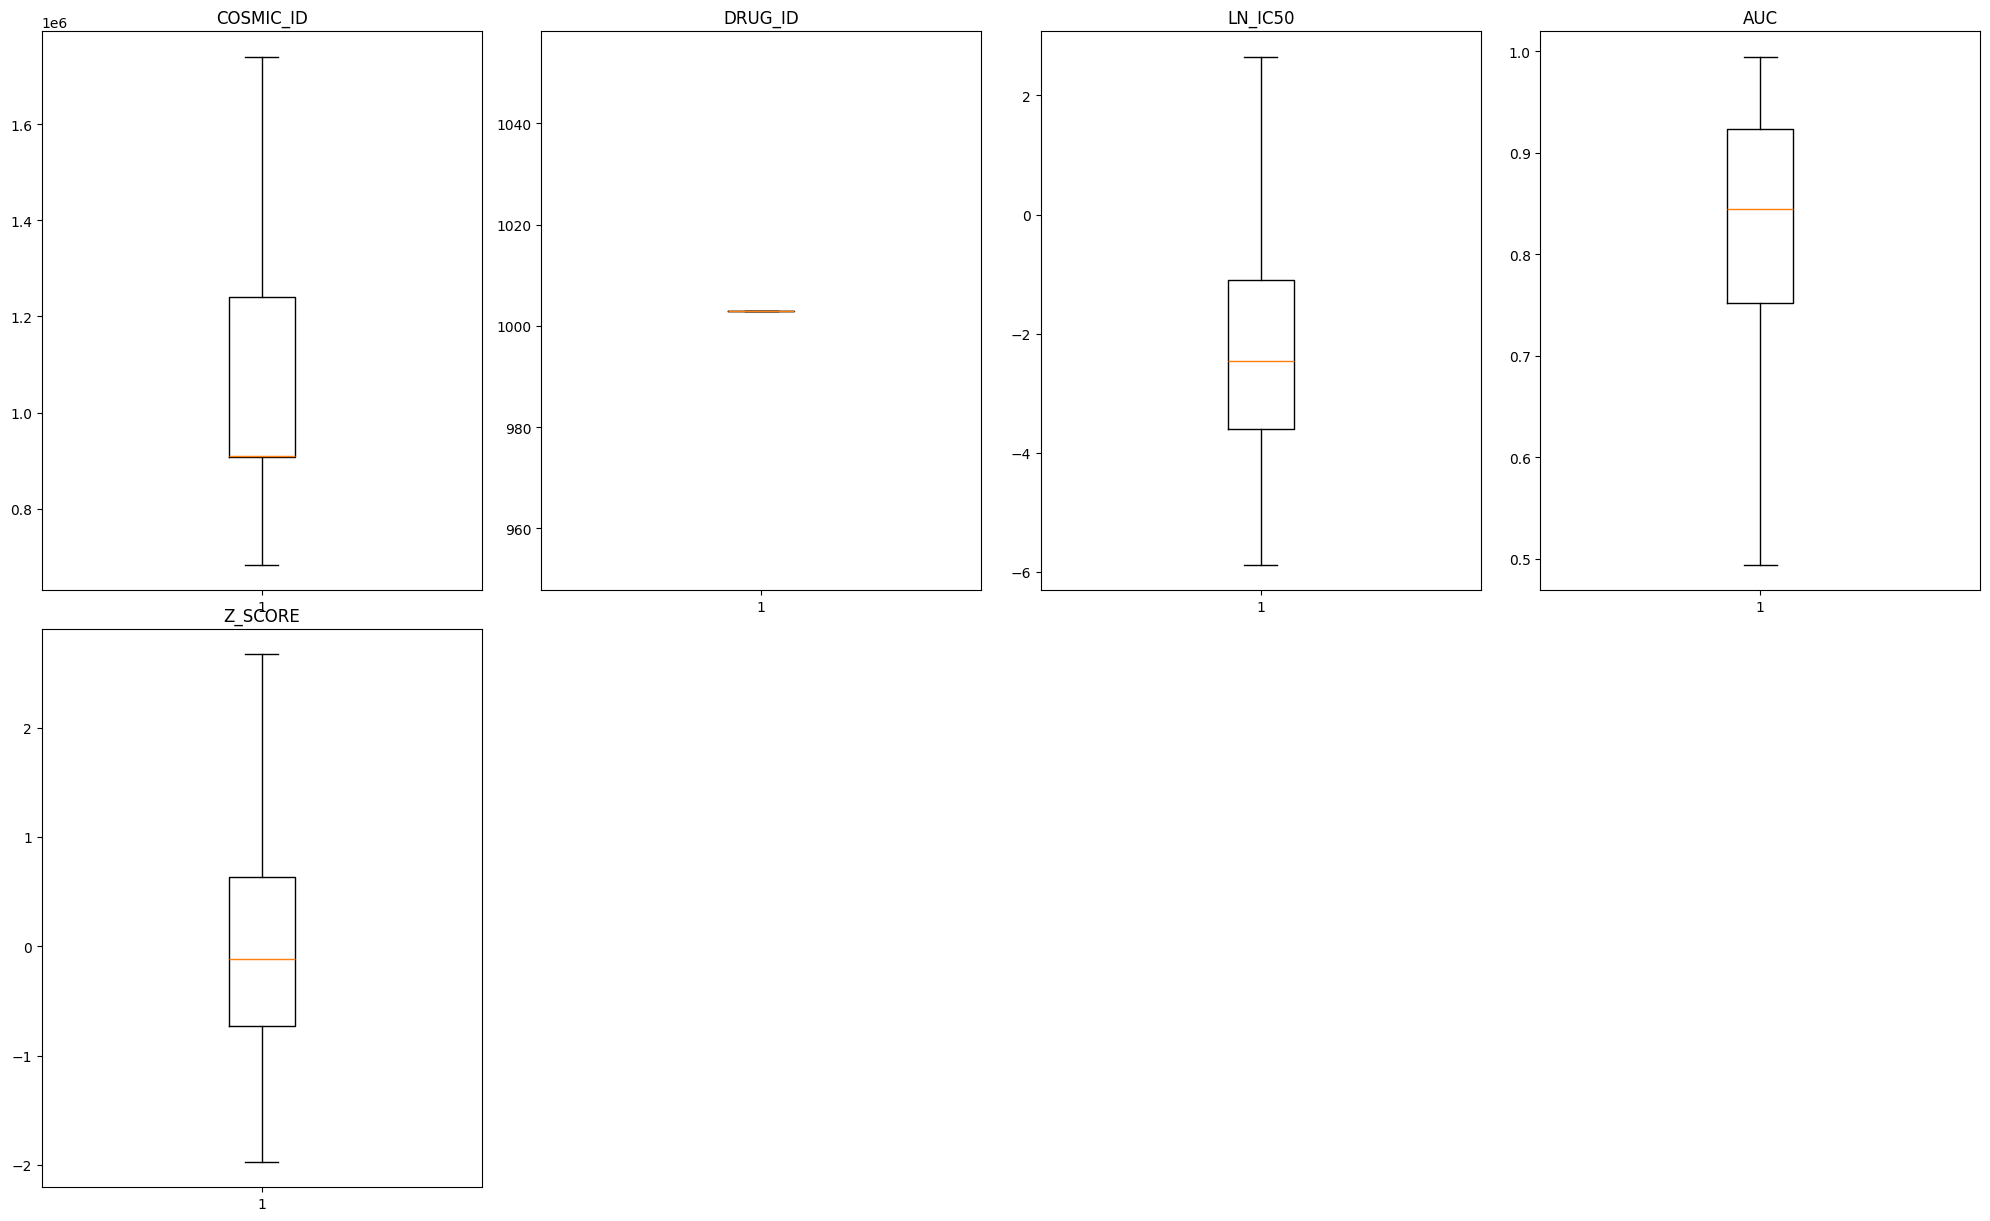

In [ ]:
# Visualize distributions after outlier treatment using boxplots
plt.figure(figsize=(20,30))

for i, variable in enumerate(numerical_col):
                     plt.subplot(5,4,i+1)
                     plt.boxplot(data[variable],whis=1.5)
                     plt.tight_layout()
                     plt.title(variable)
plt.show()

In [ ]:
# Examine class distribution of the target variable (RESISTANT)
n_true = len(data.loc[data['RESISTANT'] == 1])
n_false = len(data.loc[data['RESISTANT'] == 0])
print("Number of true cases: {0} ({1:2.2f}%)".format(n_true, (n_true / (n_true + n_false)) * 100))
print("Number of false cases: {0} ({1:2.2f}%)".format(n_false, (n_false / (n_true + n_false)) * 100))

Number of true cases: 483 (49.95%)
Number of false cases: 484 (50.05%)


##### ~50% of cell lines in this dataset are classified as Resistant (median split by LN_IC50)

### Accuracy is important, but may not be as important as recall or precision
- **Precision:** Metric of interest when we desire to minimize false positives (or Type 1 error rates)
- **Recall:** Metric of interest when we desire to minimize false negatives (or Type 2 error rates)

## Model Evaluation Criteria:

### Models can make wrong predictions:
1. Predicting a cell line is Resistant, but it is actually Sensitive (Type I Error)
2. Predicting a cell line is Sensitive, but it is actually Resistant (Type II Error)

### Which error is worse for this particular study?
* Type II Error

### Between accuracy, recall, and precision, which metric should be the primary focus?
* We want to minimize Type II error. A Type II error increases the likelihood of false negative results. If we predict that a cell line is Sensitive to Camptothecin when it is actually Resistant, that cell line would be incorrectly classified as a good treatment candidate, potentially leading to ineffective treatment decisions.

## Supervised Machine Learning

In [ ]:
# Install statsmodels (run once if not already installed; restart kernel afterward)
%pip install statsmodels


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Import libraries for machine learning and evaluation

from sklearn.model_selection import train_test_split

import statsmodels.api as sm
from sklearn import linear_model
from sklearn import metrics

# Libraries for different classifiers
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree

# Libraries for model tuning and evaluation metrics
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Make a copy of the dataframe (recommended)
data = df

### Split Dataset into features (X) and target variable (y)

In [ ]:
# Drop identifier/constant columns and leaky features
# Also drop LN_IC50 (used to create RESISTANT) and Z_SCORE (derived from LN_IC50)
cols_to_drop = ['COSMIC_ID', 'CELL_LINE_NAME', 'DRUG_ID', 'DRUG_NAME',
                'TARGET', 'TARGET_PATHWAY', 'GDSC_Tissue_descriptor_2',
                'LN_IC50', 'Z_SCORE']

# Drop columns that exist in the dataframe
cols_to_drop = [c for c in cols_to_drop if c in data.columns]
data = data.drop(columns=cols_to_drop)

X = data.drop('RESISTANT', axis=1)    # Feature variables
y = data['RESISTANT'].astype('int64') # Target variable (converted to integer)

# One-hot encode categorical features
X = pd.get_dummies(X, drop_first=True)

In [ ]:
# Split data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)
print(X_train.shape, X_test.shape)

(676, 87) (291, 87)


In [ ]:
# Check class distribution in training data (important for handling imbalance)
print(y_train.value_counts(normalize=True))

RESISTANT
0    0.5
1    0.5
Name: proportion, dtype: float64


In [ ]:
# Check to see if the class distribution is preserved after the train/test split -- the two outputs should look very similar
print("Training set distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest set distribution:")
print(y_test.value_counts(normalize=True))

Training set distribution:
RESISTANT
0    0.5
1    0.5
Name: proportion, dtype: float64

Test set distribution:
RESISTANT
0    0.501718
1    0.498282
Name: proportion, dtype: float64


In [ ]:

from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion='gini', class_weight={0: 0.15, 1: 0.85}, random_state=1)

# 2 commonly used splitting criteria are Gini impurity and information gain (entropy)
# Gini Impurity: Measures the probability of misclassifying a randomly selected observation.
    # GOAL: MINIMIZE Gini impurity at each split

# Entropy (Information Gain): Measures impurity or uncertainty. Information gain measures the reduction in entropy after a split.
    # GOAL: MINIMIZE entropy -- MAXIMIZE information gain

In [ ]:
# Train (fit) the decision tree model on the training data
model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.15, 1: 0.85}, random_state=1)

In [ ]:
# Function to generate and visualize a confusion matrix.
# A confusion matrix is used to assess classification performance by comparing predicted vs actual labels.
def make_confusion_matrix(model, X, y_actual):
    """
    Generates a confusion matrix with counts and percentages.

    Parameters:
    model: trained model
    X: feature set (e.g., X_test)
    y_actual: true labels
    """

    y_predict = model.predict(X)

    cm = confusion_matrix(y_actual, y_predict)

    df_cm = pd.DataFrame(
        cm,
        index=["Actual - No", "Actual - Yes"],
        columns=["Predicted - No", "Predicted - Yes"]
    )

    # Create labels with counts and percentages
    group_counts = [f"{value:0.0f}" for value in cm.flatten()]
    group_percentages = [f"{value:.2%}" for value in cm.flatten() / np.sum(cm)]

    labels = [f"{count}\n{percent}" for count, percent in zip(group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(2, 2)

    # Plot
    plt.figure(figsize=(10, 7))
    sns.heatmap(df_cm, annot=labels, fmt='', cmap='Blues')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.title('Confusion Matrix')

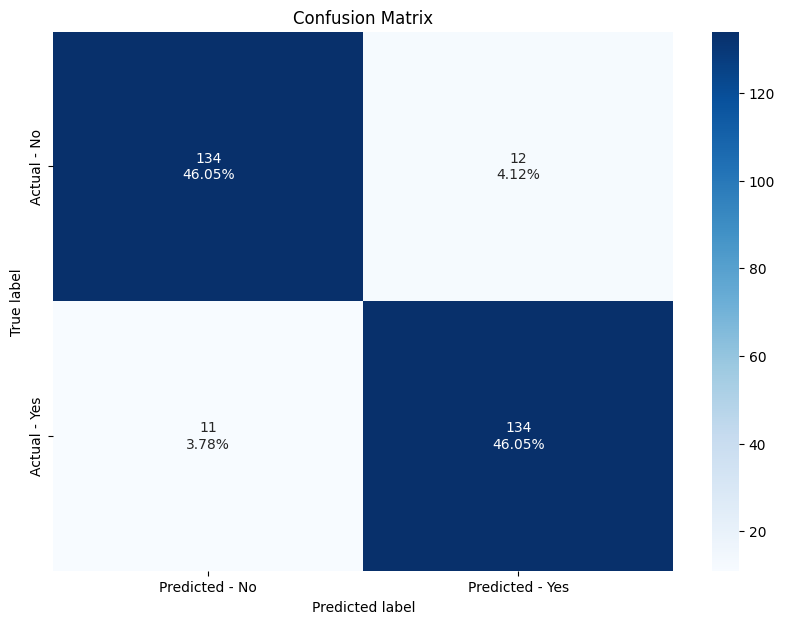

In [ ]:
# Evaluation Function: Confusion Matrix (Counts and Percentages)
make_confusion_matrix(model, X_test, y_test)

In [ ]:
# Function to calculate recall score for training and test sets
def get_recall_score(model, X_train, X_test, y_train, y_test):
    """
    Computes and prints recall for both training and test datasets.
    """

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    print("Recall on training set:", recall_score(y_train, y_pred_train))
    print("Recall on test set:", recall_score(y_test, y_pred_test))

In [ ]:
# Model Evaluation: Recall (Sensitivity) Assessment
get_recall_score(model, X_train, X_test, y_train, y_test)

Recall on training set: 1.0
Recall on test set: 0.9241379310344827


In [ ]:
# Extract feature names (exclude target variable 'RESISTANT')
feature_names = X_train.columns.tolist()
print(feature_names)

['AUC', 'TCGA_DESC_ALL', 'TCGA_DESC_BLCA', 'TCGA_DESC_BRCA', 'TCGA_DESC_CESC', 'TCGA_DESC_CLL', 'TCGA_DESC_COREAD', 'TCGA_DESC_DLBC', 'TCGA_DESC_ESCA', 'TCGA_DESC_GBM', 'TCGA_DESC_HNSC', 'TCGA_DESC_KIRC', 'TCGA_DESC_LAML', 'TCGA_DESC_LCML', 'TCGA_DESC_LGG', 'TCGA_DESC_LIHC', 'TCGA_DESC_LUAD', 'TCGA_DESC_LUSC', 'TCGA_DESC_MB', 'TCGA_DESC_MESO', 'TCGA_DESC_MM', 'TCGA_DESC_NB', 'TCGA_DESC_OTHER', 'TCGA_DESC_OV', 'TCGA_DESC_PAAD', 'TCGA_DESC_PRAD', 'TCGA_DESC_SCLC', 'TCGA_DESC_SKCM', 'TCGA_DESC_STAD', 'TCGA_DESC_THCA', 'TCGA_DESC_UCEC', 'TCGA_DESC_UNCLASSIFIED', 'GDSC_Tissue_descriptor_1_bone', 'GDSC_Tissue_descriptor_1_breast', 'GDSC_Tissue_descriptor_1_digestive_system', 'GDSC_Tissue_descriptor_1_kidney', 'GDSC_Tissue_descriptor_1_large_intestine', 'GDSC_Tissue_descriptor_1_leukemia', 'GDSC_Tissue_descriptor_1_lung', 'GDSC_Tissue_descriptor_1_lung_NSCLC', 'GDSC_Tissue_descriptor_1_lung_SCLC', 'GDSC_Tissue_descriptor_1_lymphoma', 'GDSC_Tissue_descriptor_1_myeloma', 'GDSC_Tissue_descriptor

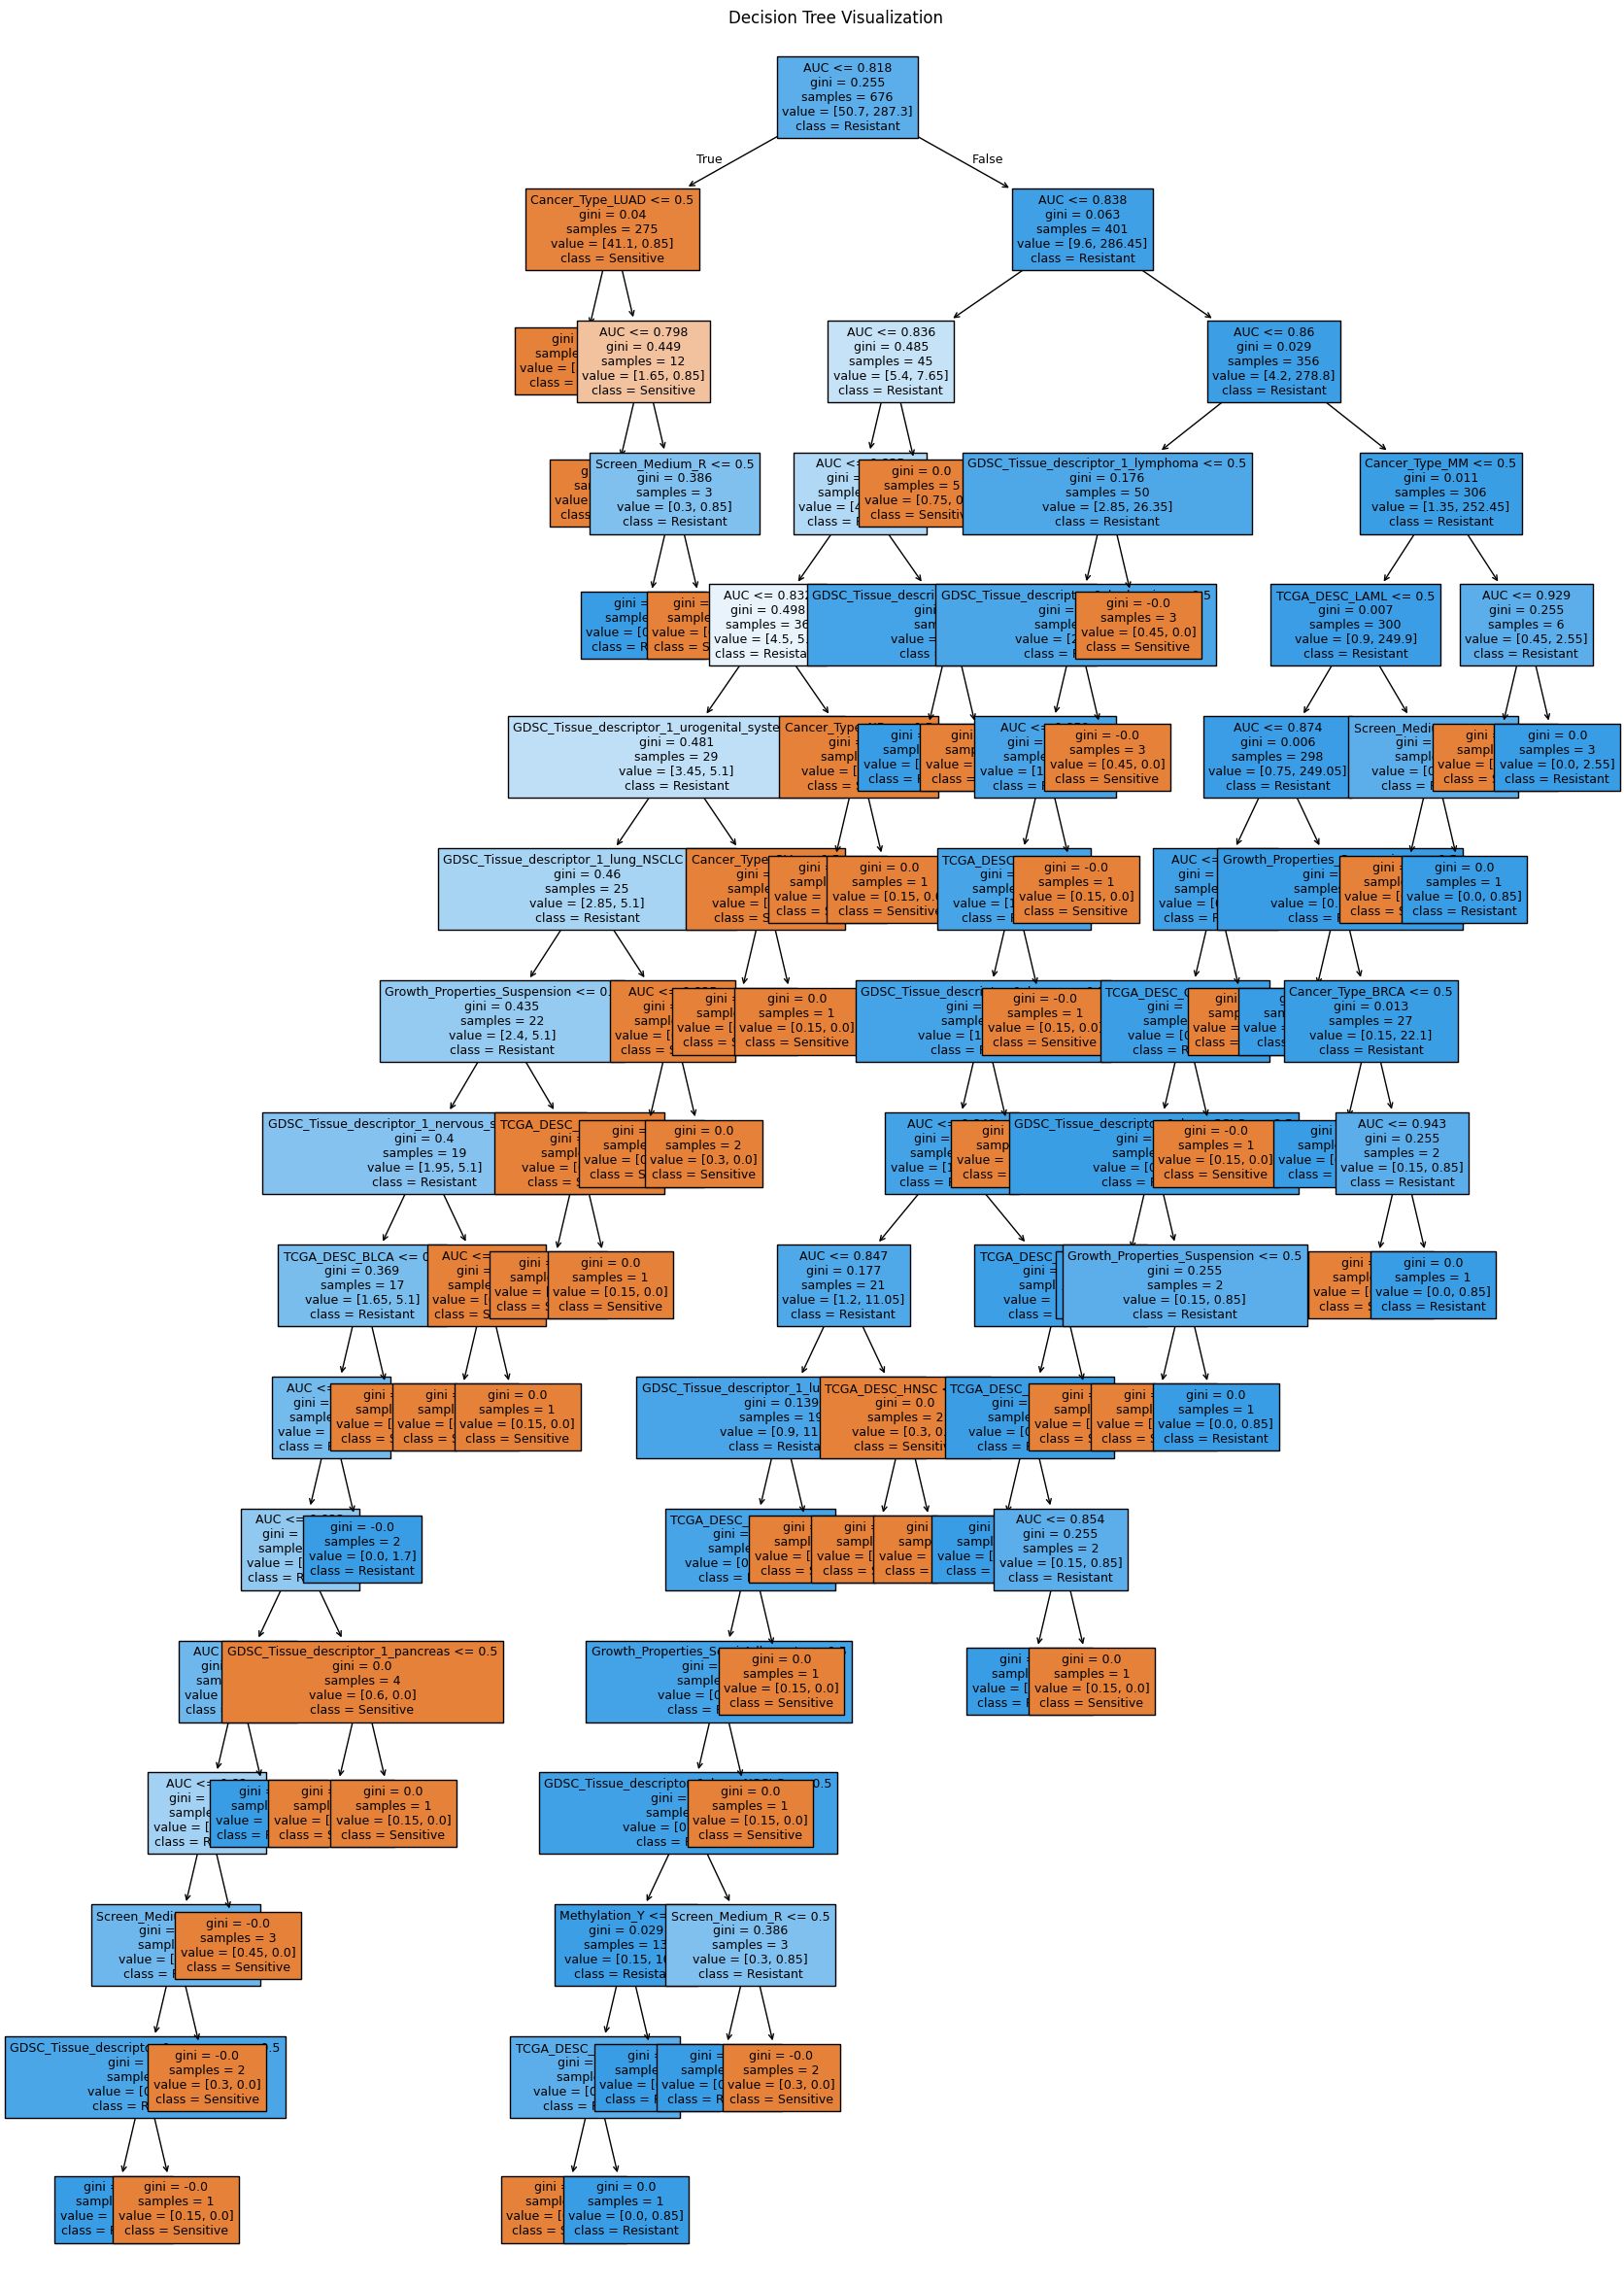

In [ ]:
# Visualize the trained decision tree

from sklearn import tree

plt.figure(figsize=(20, 30))

out = tree.plot_tree(
    model,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=["Sensitive", "Resistant"]
)

# Ensure arrows are clearly visible
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor('black')
        arrow.set_linewidth(1)

plt.title("Decision Tree Visualization")
plt.show()

In [ ]:
# Model Interpretation: Decision Tree Rules (Text Representation)

print(tree.export_text(model, feature_names=feature_names, show_weights=True))

|--- AUC <= 0.82
|   |--- Cancer_Type_LUAD <= 0.50
|   |   |--- weights: [39.45, 0.00] class: 0
|   |--- Cancer_Type_LUAD >  0.50
|   |   |--- AUC <= 0.80
|   |   |   |--- weights: [1.35, 0.00] class: 0
|   |   |--- AUC >  0.80
|   |   |   |--- Screen_Medium_R <= 0.50
|   |   |   |   |--- weights: [0.00, 0.85] class: 1
|   |   |   |--- Screen_Medium_R >  0.50
|   |   |   |   |--- weights: [0.30, 0.00] class: 0
|--- AUC >  0.82
|   |--- AUC <= 0.84
|   |   |--- AUC <= 0.84
|   |   |   |--- AUC <= 0.83
|   |   |   |   |--- AUC <= 0.83
|   |   |   |   |   |--- GDSC_Tissue_descriptor_1_urogenital_system <= 0.50
|   |   |   |   |   |   |--- GDSC_Tissue_descriptor_1_lung_NSCLC <= 0.50
|   |   |   |   |   |   |   |--- Growth_Properties_Suspension <= 0.50
|   |   |   |   |   |   |   |   |--- GDSC_Tissue_descriptor_1_nervous_system <= 0.50
|   |   |   |   |   |   |   |   |   |--- TCGA_DESC_BLCA <= 0.50
|   |   |   |   |   |   |   |   |   |   |--- AUC <= 0.83
|   |   |   |   |   |   |   |   |   

In [ ]:
# Model Interpretation: Feature Importance (Gini Importance)

# The importance of a feature is computed as the normalized total reduction
# in impurity (Gini) contributed by that feature across all splits.

feature_importance = pd.DataFrame(
    model.feature_importances_,
    columns=["Importance"],
    index=X_train.columns
).sort_values(by="Importance", ascending=False)

print(feature_importance)

                                        Importance
AUC                                       0.896943
Screen_Medium_R                           0.018307
GDSC_Tissue_descriptor_1_leukemia         0.008911
GDSC_Tissue_descriptor_1_lymphoma         0.008636
Growth_Properties_Suspension              0.008116
...                                            ...
GDSC_Tissue_descriptor_1_neuroblastoma    0.000000
GDSC_Tissue_descriptor_1_skin             0.000000
TCGA_DESC_CLL                             0.000000
Cancer_Type_ALL                           0.000000
GDSC_Tissue_descriptor_1_thyroid          0.000000

[87 rows x 1 columns]


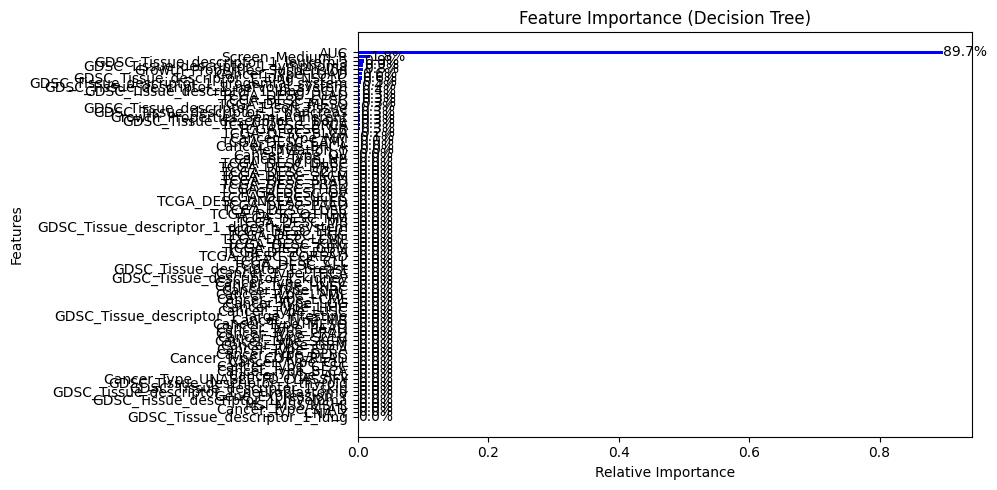

In [ ]:
# Model Interpretation: Feature Importance Plot (with percentages)

importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 5))
plt.title('Feature Importance (Decision Tree)')

bars = plt.barh(range(len(indices)), importances[indices], color='blue', align='center')

plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.ylabel('Features')

# Add percentage labels to bars
for i, v in enumerate(importances[indices]):
    plt.text(v + 0.001, i, f"{v*100:.1f}%", va='center')

plt.tight_layout()
plt.show()

## Hyperparameter Tuning to Reduce Overfitting
To help reduce overfitting and improve generalization, I will use **Grid Search** to tune the model's hyperparameters.

### Example of Hyperparameter Tuning: Decision Tree using Grid Search (optimize recall)

In [ ]:
# Import GridSearchCV and other libraries
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import make_scorer, recall_score

# Define base model
estimator = DecisionTreeClassifier(
    random_state=1,
    class_weight={0: 0.30, 1: 0.70}
)

# Define hyperparameter grid
param_grid = {
    'max_depth': np.arange(15, 27),
    'criterion': ['entropy', 'gini'],
    'splitter': ['best', 'random'],
    'min_impurity_decrease': [0.0001, 0.001],
    'max_features': ['log2', 'sqrt']
}

# Define scoring metric
scorer = make_scorer(recall_score)

# Define stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

# Perform grid search with the correct estimator
grid_obj = GridSearchCV(
    estimator=estimator,
    param_grid=param_grid,
    scoring=scorer,
    cv=cv
)

grid_obj.fit(X_train, y_train)

# Extract best model
estimator = grid_obj.best_estimator_

# Fit the best algorithm to the data
estimator.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.3, 1: 0.7}, criterion='entropy',
                       max_depth=np.int64(15), max_features='sqrt',
                       min_impurity_decrease=0.001, random_state=1,
                       splitter='random')

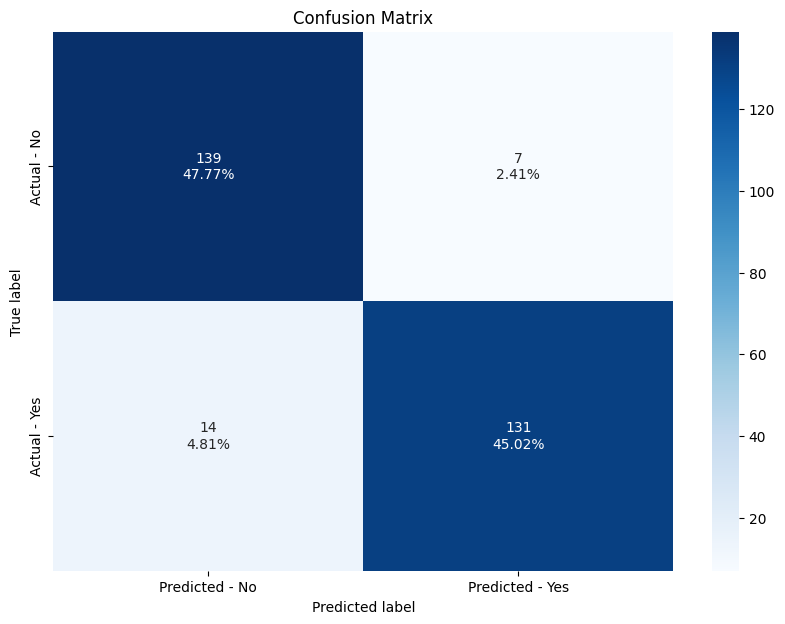

In [ ]:
make_confusion_matrix(estimator, X_test, y_test)

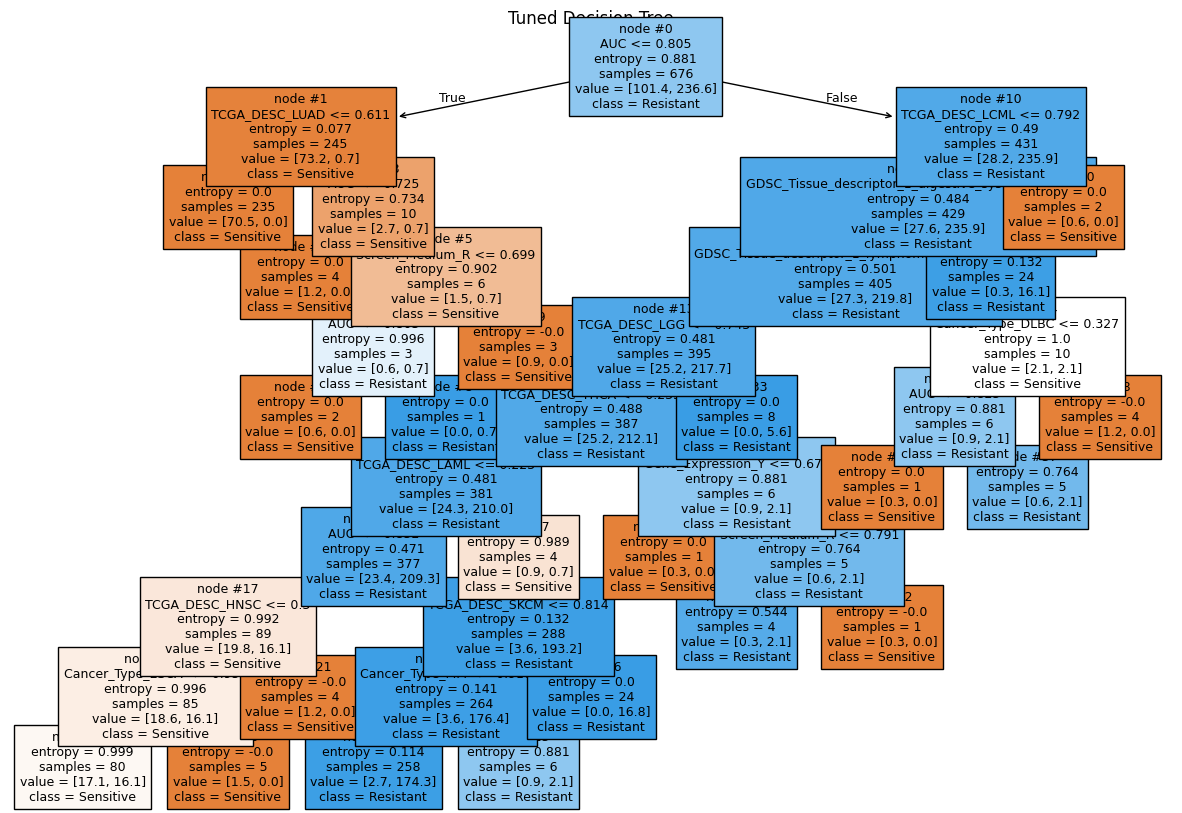

In [ ]:
# Model Interpretation: Tuned Decision Tree Visualization

plt.figure(figsize=(15, 10))

out = tree.plot_tree(
    estimator,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=True,
    class_names=["Sensitive", "Resistant"]
)

# Ensure arrows are clearly visible
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor('black')
        arrow.set_linewidth(1)

plt.title("Tuned Decision Tree")
plt.show()

In [ ]:
# Model Interpretation: Tuned Decision Tree Rules (Text-Based)

print(tree.export_text(estimator, feature_names=feature_names, show_weights=False))

|--- AUC <= 0.80
|   |--- TCGA_DESC_LUAD <= 0.61
|   |   |--- class: 0
|   |--- TCGA_DESC_LUAD >  0.61
|   |   |--- AUC <= 0.73
|   |   |   |--- class: 0
|   |   |--- AUC >  0.73
|   |   |   |--- Screen_Medium_R <= 0.70
|   |   |   |   |--- AUC <= 0.80
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- AUC >  0.80
|   |   |   |   |   |--- class: 1
|   |   |   |--- Screen_Medium_R >  0.70
|   |   |   |   |--- class: 0
|--- AUC >  0.80
|   |--- TCGA_DESC_LCML <= 0.79
|   |   |--- GDSC_Tissue_descriptor_1_digestive_system <= 0.31
|   |   |   |--- GDSC_Tissue_descriptor_1_lymphoma <= 0.11
|   |   |   |   |--- TCGA_DESC_LGG <= 0.74
|   |   |   |   |   |--- TCGA_DESC_THCA <= 0.23
|   |   |   |   |   |   |--- TCGA_DESC_LAML <= 0.22
|   |   |   |   |   |   |   |--- AUC <= 0.85
|   |   |   |   |   |   |   |   |--- TCGA_DESC_HNSC <= 0.30
|   |   |   |   |   |   |   |   |   |--- Cancer_Type_ESCA <= 0.95
|   |   |   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |   |   

In [ ]:
# Then check recall
get_recall_score(estimator, X_train, X_test, y_train, y_test)

Recall on training set: 0.9289940828402367
Recall on test set: 0.903448275862069


In [ ]:
# Check what the tuned model is predicting
y_pred = estimator.predict(X_test)

print("Predicted class counts:")
print(pd.Series(y_pred).value_counts())

print("\nActual class counts:")
print(pd.Series(y_test).value_counts())

Predicted class counts:
0    153
1    138
Name: count, dtype: int64

Actual class counts:
RESISTANT
0    146
1    145
Name: count, dtype: int64


In [ ]:
# Model Interpretation: Feature Importance (Gini Importance – Tuned Decision Tree)

feature_importance = pd.DataFrame(
    estimator.feature_importances_,
    columns=["Importance"],
    index=X_train.columns
).sort_values(by="Importance", ascending=False)

print(feature_importance)

                                   Importance
AUC                                  0.907657
TCGA_DESC_LUAD                       0.013700
GDSC_Tissue_descriptor_1_lymphoma    0.012399
Cancer_Type_MM                       0.011314
TCGA_DESC_LCML                       0.008283
...                                       ...
GDSC_Tissue_descriptor_1_bone        0.000000
TCGA_DESC_UNCLASSIFIED               0.000000
TCGA_DESC_UCEC                       0.000000
TCGA_DESC_STAD                       0.000000
Methylation_Y                        0.000000

[87 rows x 1 columns]


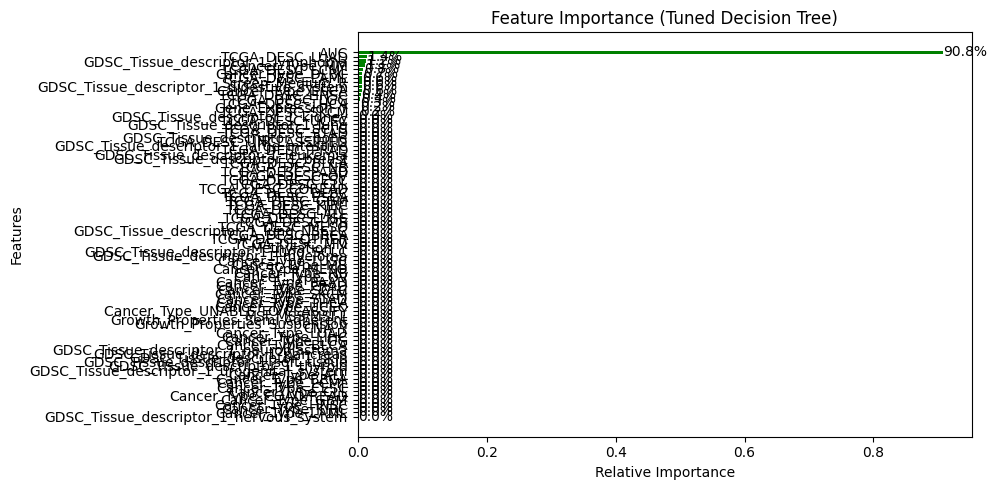

In [ ]:
# Model Interpretation: Feature Importance (Tuned Decision Tree)

importances = estimator.feature_importances_
indices = np.argsort(importances)[::-1]  # sort descending

plt.figure(figsize=(10, 5))
plt.title('Feature Importance (Tuned Decision Tree)')

bars = plt.barh(range(len(indices)), importances[indices], color='green', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])

plt.xlabel('Relative Importance')
plt.ylabel('Features')

# Put most important feature at the top
plt.gca().invert_yaxis()

# Add percentage labels
for i, v in enumerate(importances[indices]):
    plt.text(v + 0.001, i, f"{v*100:.1f}%", va='center')

plt.tight_layout()
plt.show()

### Comparing Decision Trees

In [ ]:
# Compute recall scores for both models

# Initial model
y_pred_train_initial = model.predict(X_train)
y_pred_test_initial = model.predict(X_test)

train_recall_initial = recall_score(y_train, y_pred_train_initial)
test_recall_initial = recall_score(y_test, y_pred_test_initial)

# Tuned model
y_pred_train_tuned = estimator.predict(X_train)
y_pred_test_tuned = estimator.predict(X_test)

train_recall_tuned = recall_score(y_train, y_pred_train_tuned)
test_recall_tuned = recall_score(y_test, y_pred_test_tuned)

# Create comparison dataframe
comparison_frame_dtree = pd.DataFrame({
    'Model': ['Initial decision tree model', 'Decision tree with GridSearchCV'],
    'Train_Recall': [train_recall_initial, train_recall_tuned],
    'Test_Recall': [test_recall_initial, test_recall_tuned]
})

comparison_frame_dtree

,Model,Train_Recall,Test_Recall
0,Initial decision tree model,1.000000,0.924138
1,Decision tree with GridSearchCV,0.928994,0.903448


## Model Evaluation Criteria - Which Error Is More Important?

In this context, the more critical error is:

> **Type II Error (False Negative)**

Failing to identify a cell line that is truly Resistant may result in:
- incorrect classification as a treatment candidate  
- ineffective treatment decisions  
- missed opportunity to investigate resistance mechanisms  

---

### Which Metric Should Be Optimized?

To reduce false negatives, we aim to maximize Recall (Sensitivity).

- Recall = True Positives / (True Positives + False Negatives)
- A higher recall means:
  - fewer false negatives  
  - more true cases correctly identified  

---

### Clinical Interpretation

If a model predicts that a cell line is Sensitive when it is actually Resistant (false negative),
the treatment may be incorrectly recommended and could potentially lead to ineffective treatment regimen.

However, if a model predicts Resistance when a cell line is actually Sensitive (false positive),
further investigation would occur. This would be undesirable for the patient but prefered over incorrect treatment.

# ***********************************************************************************

## Supervised Learning

In [ ]:
# Libraries for different classifiers
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn import tree
from sklearn.metrics import f1_score

# Libraries for model tuning and evaluation
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score
)

In [ ]:
# Create a copy of the original dataset to preserve the raw data
data_2 = df.copy()

In [ ]:
# Drop identifier/constant columns and leaky features
cols_to_drop = ['COSMIC_ID', 'CELL_LINE_NAME', 'DRUG_ID', 'DRUG_NAME',
                'TARGET', 'TARGET_PATHWAY', 'GDSC_Tissue_descriptor_2',
                'LN_IC50', 'Z_SCORE']

cols_to_drop = [c for c in cols_to_drop if c in data_2.columns]
data_2 = data_2.drop(columns=cols_to_drop)

# Separate dataset into feature variables (X) and target variable (RESISTANT)
X = data_2.drop('RESISTANT', axis=1)
y = data_2['RESISTANT']

# One-hot encode categorical features
X = pd.get_dummies(X, drop_first=True)

In [ ]:
# Split data into training and testing sets (70/30 split)
# random_state ensures reproducibility; stratify=y preserves class distribution across splits

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y
)

print(X_train.shape, X_test.shape)

(676, 87) (291, 87)


## Decision Tree

In [ ]:
# Hyperparameter Tuning: Decision Tree (Grid Search with Recall Optimization)

# Define base model
dtree_estimator = DecisionTreeClassifier(
    class_weight={0: 0.35, 1: 0.65},
    random_state=1
)

# Define hyperparameter grid
param_grid = {
    'max_depth': np.arange(2, 10),
    'min_samples_leaf': [5, 7, 10, 15],
    'max_leaf_nodes': [2, 3, 5, 10, 15],
    'min_impurity_decrease': [0.0001, 0.001, 0.01, 0.1]
}

# Run grid search
grid_search = GridSearchCV(
    estimator=dtree_estimator,
    param_grid=param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Extract best model
dtree_estimator = grid_search.best_estimator_

In [ ]:
# Model Evaluation: Accuracy, Recall, Precision, and F1-Score
def get_metrics_score(model, X_train, X_test, y_train, y_test, verbose=True):
    """
    Computes accuracy, recall, precision, and F1-score for training and test sets.
    """

    # Predictions
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Accuracy
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)

    # Recall (minimizes false negatives)
    train_recall = recall_score(y_train, y_pred_train)
    test_recall = recall_score(y_test, y_pred_test)

    # Precision (minimizes false positives)
    train_precision = precision_score(y_train, y_pred_train)
    test_precision = precision_score(y_test, y_pred_test)

    # F1-score (balance between precision and recall)
    train_f1 = f1_score(y_train, y_pred_train)
    test_f1 = f1_score(y_test, y_pred_test)

    if verbose:
        print(f"Accuracy (Train):  {train_acc:.3f}")
        print(f"Accuracy (Test):   {test_acc:.3f}")
        print(f"Recall (Train):    {train_recall:.3f}")
        print(f"Recall (Test):     {test_recall:.3f}")
        print(f"Precision (Train): {train_precision:.3f}")
        print(f"Precision (Test):  {test_precision:.3f}")
        print(f"F1-score (Train):  {train_f1:.3f}")
        print(f"F1-score (Test):   {test_f1:.3f}")

    return [
        train_acc, test_acc,
        train_recall, test_recall,
        train_precision, test_precision,
        train_f1, test_f1
    ]

In [ ]:
# Function to create a confusion matrix
def make_confusion_matrix(model, X, y_actual):
    y_predict = model.predict(X)
    cm = confusion_matrix(y_actual, y_predict, labels=[0, 1])

    df_cm = pd.DataFrame(
        cm,
        index=["Actual - No", "Actual - Yes"],
        columns=["Predicted - No", "Predicted - Yes"]
    )

    group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in cm.flatten() / np.sum(cm)]
    plot_labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_counts, group_percentages)]
    plot_labels = np.asarray(plot_labels).reshape(2, 2)

    plt.figure(figsize=(10, 7))
    sns.heatmap(df_cm, annot=plot_labels, fmt='', cmap='Blues')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.title('Confusion Matrix')

Accuracy (Train):  1.000
Accuracy (Test):   0.931
Recall (Train):    1.000
Recall (Test):     0.931
Precision (Train): 1.000
Precision (Test):  0.931
F1-score (Train):  1.000
F1-score (Test):   0.931


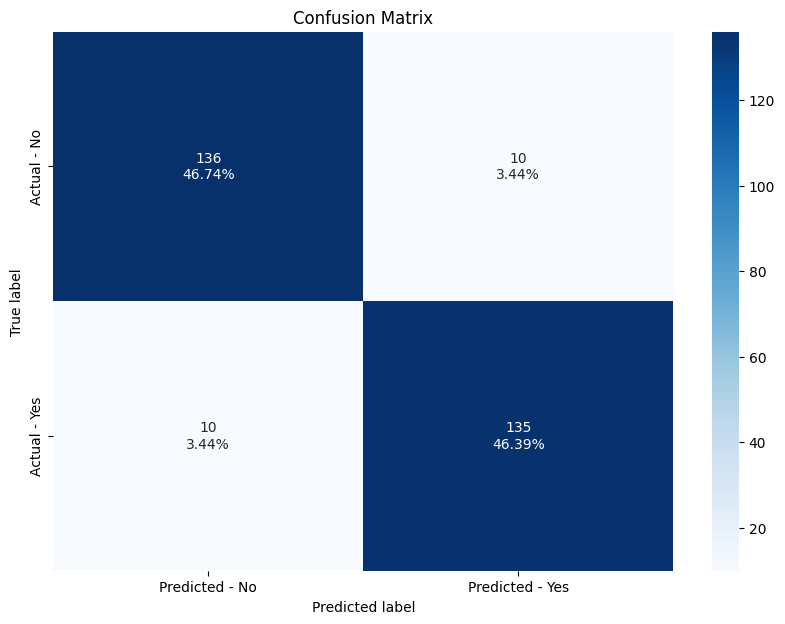

In [ ]:
# Train and Evaluate Initial Decision Tree Model
# Fit the model
d_tree = DecisionTreeClassifier(random_state=1)
d_tree.fit(X_train, y_train)

# Calculate metrics
get_metrics_score(d_tree, X_train, X_test, y_train, y_test)

# Create the confusion matrix
make_confusion_matrix(d_tree, X_test, y_test)

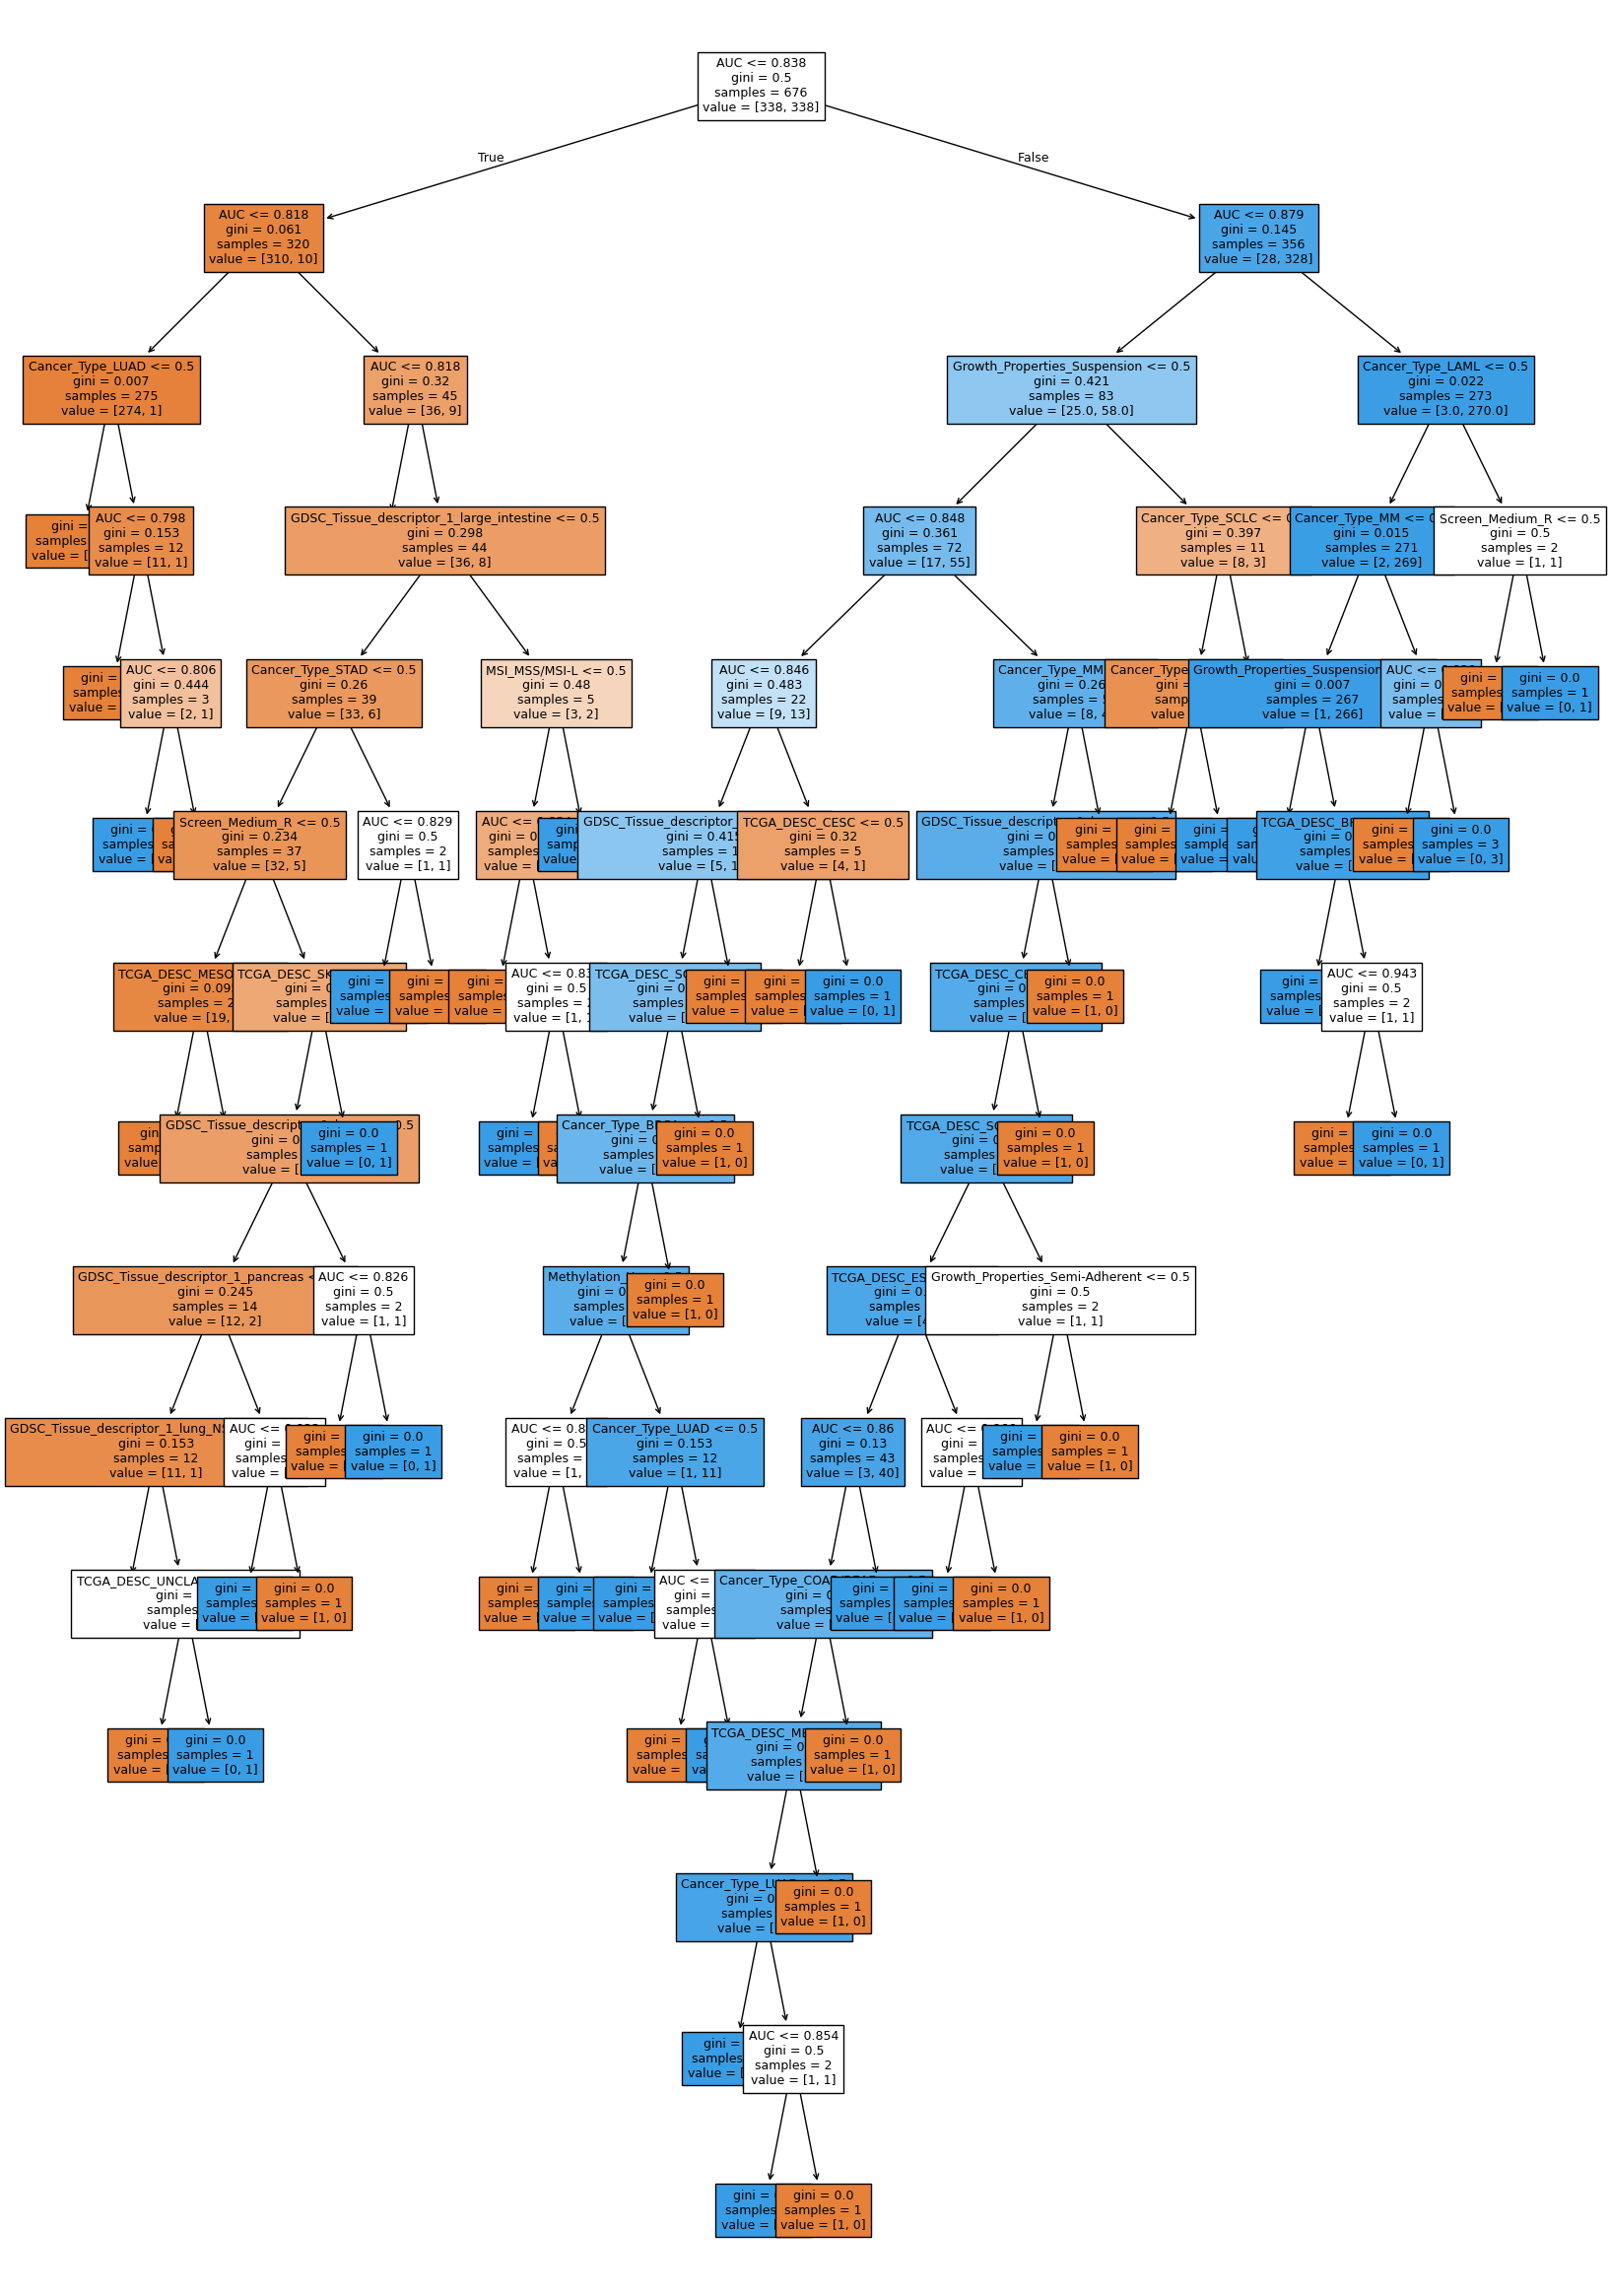

In [ ]:
# Visualize decision tree

plt.figure(figsize=(20,30))
out = tree.plot_tree(d_tree, feature_names=feature_names, filled=True, fontsize=9, node_ids=False, class_names=None)
# Code below will add arrows to the decision tree split if they are missing
for o in out:
     arrow = o.arrow_patch
     if arrow is not None:
        arrow.set_edgecolor('black')
        arrow.set_linewidth(1)
plt.show()

In [ ]:
# Print text report showing the rules of the decision tree

print(tree.export_text(d_tree, feature_names=feature_names, show_weights=True))

|--- AUC <= 0.84
|   |--- AUC <= 0.82
|   |   |--- Cancer_Type_LUAD <= 0.50
|   |   |   |--- weights: [263.00, 0.00] class: 0
|   |   |--- Cancer_Type_LUAD >  0.50
|   |   |   |--- AUC <= 0.80
|   |   |   |   |--- weights: [9.00, 0.00] class: 0
|   |   |   |--- AUC >  0.80
|   |   |   |   |--- AUC <= 0.81
|   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |--- AUC >  0.81
|   |   |   |   |   |--- weights: [2.00, 0.00] class: 0
|   |--- AUC >  0.82
|   |   |--- AUC <= 0.82
|   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |--- AUC >  0.82
|   |   |   |--- GDSC_Tissue_descriptor_1_large_intestine <= 0.50
|   |   |   |   |--- Cancer_Type_STAD <= 0.50
|   |   |   |   |   |--- Screen_Medium_R <= 0.50
|   |   |   |   |   |   |--- TCGA_DESC_MESO <= 0.50
|   |   |   |   |   |   |   |--- weights: [19.00, 0.00] class: 0
|   |   |   |   |   |   |--- TCGA_DESC_MESO >  0.50
|   |   |   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |   |--- Screen_Med

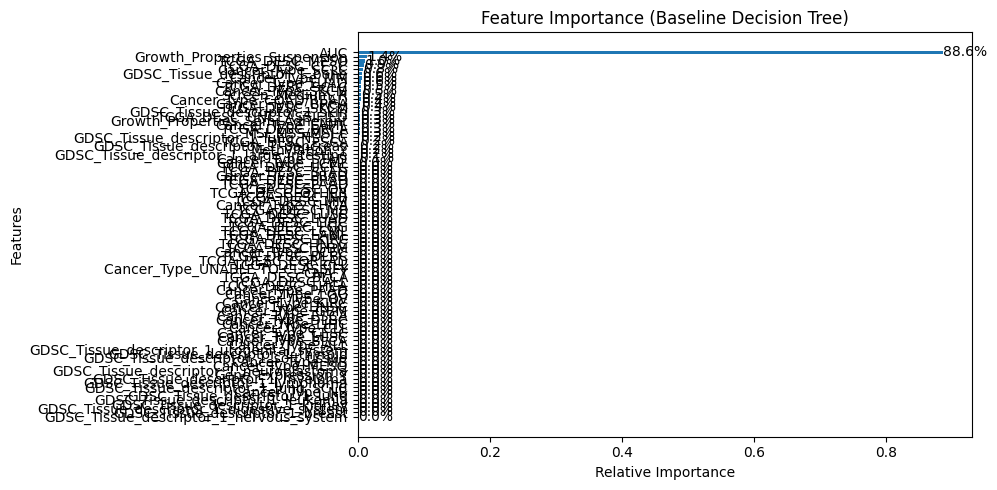

In [ ]:
# Model Interpretation: Feature Importance (Baseline Decision Tree)

importances = d_tree.feature_importances_
indices = np.argsort(importances)[::-1]  # sort descending

plt.figure(figsize=(10, 5))
plt.title('Feature Importance (Baseline Decision Tree)')

plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])

plt.xlabel('Relative Importance')
plt.ylabel('Features')

# Show most important feature at the top
plt.gca().invert_yaxis()

# Add percentage labels
for i, v in enumerate(importances[indices]):
    plt.text(v + 0.001, i, f"{v*100:.1f}%", va='center')

plt.tight_layout()
plt.show()

## Tuned Decision Tree (with Grid SearchCV)

In [ ]:
dtree_tuned = DecisionTreeClassifier(class_weight={0:0.35, 1:0.65}, random_state=1)

parameters = {'max_depth': np.arange(2,10),
              'min_samples_leaf': [5, 7, 10, 15],
              'max_leaf_nodes' : [2, 3, 5, 10, 15],
              'min_impurity_decrease': [0.0001, 0.001, 0.01, 0.1]
             }

scorer = metrics.make_scorer(metrics.recall_score)

grid_obj = GridSearchCV(dtree_estimator, parameters, scoring=scorer, n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

dtree_tuned = grid_obj.best_estimator_

dtree_tuned.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.35, 1: 0.65}, max_depth=np.int64(2),
                       max_leaf_nodes=2, min_impurity_decrease=0.0001,
                       min_samples_leaf=5, random_state=1)

Accuracy (Train):  0.944
Accuracy (Test):   0.948
Recall (Train):    0.970
Recall (Test):     0.952
Precision (Train): 0.921
Precision (Test):  0.945
F1-score (Train):  0.945
F1-score (Test):   0.948


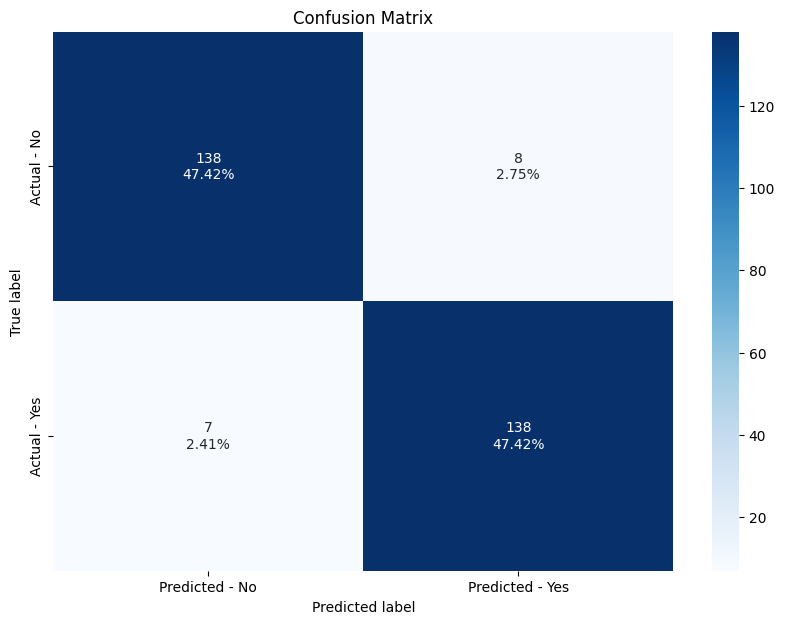

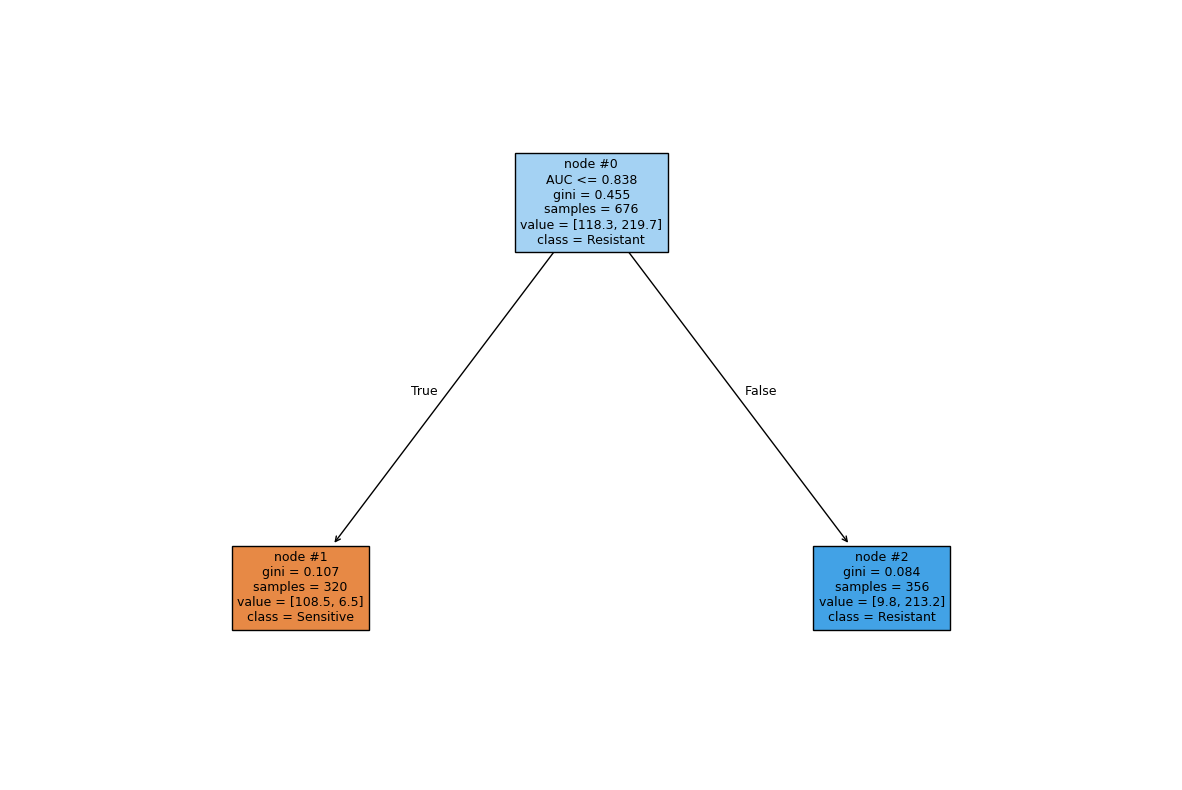

In [ ]:
# Evaluate Tuned Decision Tree Model

get_metrics_score(dtree_tuned, X_train, X_test, y_train, y_test)

make_confusion_matrix(dtree_tuned, X_test, y_test)

# Visualize tuned decision tree
plt.figure(figsize=(15, 10))
out = tree.plot_tree(
    dtree_tuned,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=True,
    class_names=["Sensitive", "Resistant"]
)

for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor('black')
        arrow.set_linewidth(1)

plt.show()

## Random Forest


Accuracy (Train):  1.000
Accuracy (Test):   0.918
Recall (Train):    1.000
Recall (Test):     0.931
Precision (Train): 1.000
Precision (Test):  0.906
F1-score (Train):  1.000
F1-score (Test):   0.918


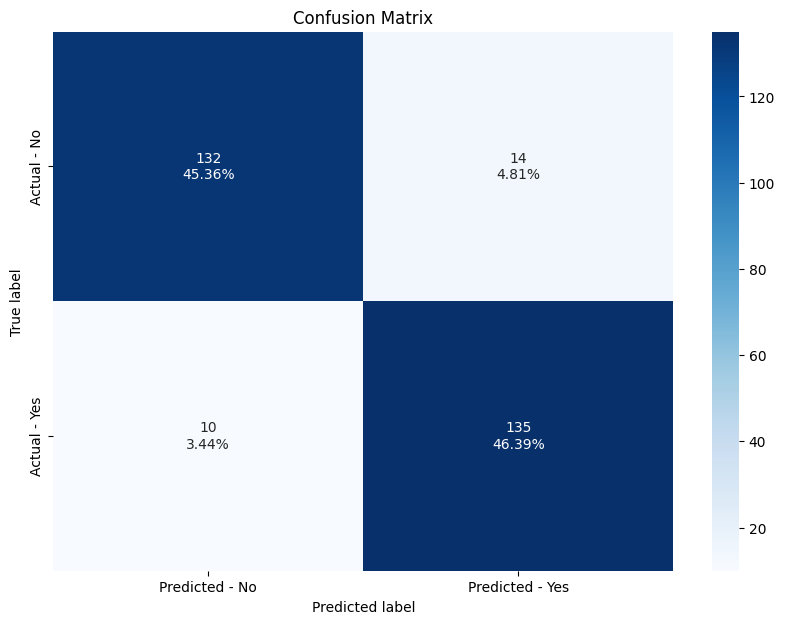

In [ ]:
# Train and Evaluate Random Forest Model
# Fit the model
rf_estimator = RandomForestClassifier(random_state=1)
rf_estimator.fit(X_train, y_train)

# Calculate metrics
get_metrics_score(rf_estimator, X_train, X_test, y_train, y_test)

# Create the confusion matrix
make_confusion_matrix(rf_estimator, X_test, y_test)

## Tuned Random Forest (Grid SearchCV)

In [ ]:
%%time
# Train and Tune Random Forest (Grid Search – Recall Optimization)

rf_tuned = RandomForestClassifier(
    class_weight={0: 0.35, 1: 0.65},
    random_state=1,
    bootstrap=True
)

parameters = {
    'max_depth': list(np.arange(3, 10, 1)),
    'max_features': [0.6, 0.7, 0.8, 0.9, 1.0],
    'max_samples': [0.7, 0.8, 0.9, 1.0],
    'min_samples_split': [2, 5, 10, 15],
    'n_estimators': [50, 100, 150],
    'min_impurity_decrease': [0.0001, 0.001, 0.01]
}

grid_obj = GridSearchCV(
    rf_tuned,
    parameters,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

grid_obj.fit(X_train, y_train)

rf_tuned = grid_obj.best_estimator_

CPU times: user 12.5 s, sys: 2.21 s, total: 14.7 s
Wall time: 5min 31s


In [ ]:
# Best Model Parameters and Cross-Validated Recall Performance
print("Best Parameters:", grid_obj.best_params_)
print("Best Cross-Validated Recall:", grid_obj.best_score_)

Best Parameters: {'max_depth': np.int64(3), 'max_features': 0.6, 'max_samples': 0.7, 'min_impurity_decrease': 0.01, 'min_samples_split': 2, 'n_estimators': 50}
Best Cross-Validated Recall: 0.9643985952589992


Accuracy (Train):  0.945
Accuracy (Test):   0.948
Recall (Train):    0.970
Recall (Test):     0.952
Precision (Train): 0.924
Precision (Test):  0.945
F1-score (Train):  0.947
F1-score (Test):   0.948


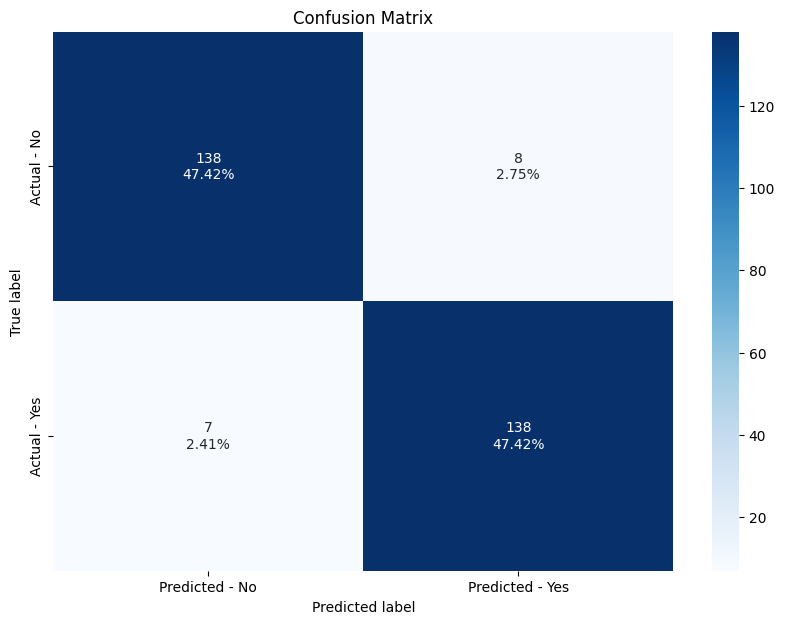

In [ ]:
# Evaluate Tuned Random Forest Model

# Calculate performance metrics
get_metrics_score(rf_tuned, X_train, X_test, y_train, y_test)

# Create confusion matrix
make_confusion_matrix(rf_tuned, X_test, y_test)

## Bagging Classifier

Accuracy (Train):  0.990
Accuracy (Test):   0.921
Recall (Train):    0.985
Recall (Test):     0.903
Precision (Train): 0.994
Precision (Test):  0.936
F1-score (Train):  0.990
F1-score (Test):   0.919


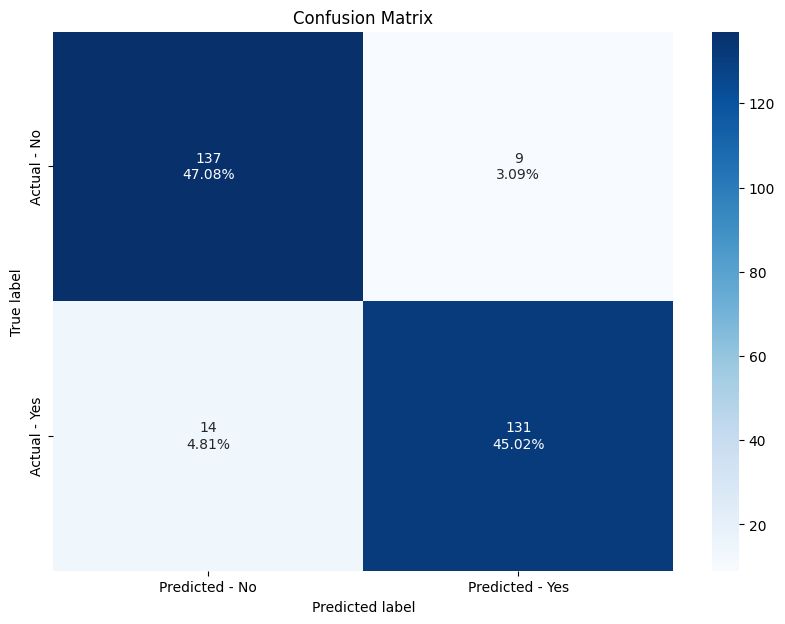

In [ ]:
# Train and Evaluate Bagging Classifier
# Fit the model
bagging_classifier = BaggingClassifier(random_state=1)
bagging_classifier.fit(X_train, y_train)

# Calculate metrics
get_metrics_score(bagging_classifier, X_train, X_test, y_train, y_test)

# Create the confusion matrix
make_confusion_matrix(bagging_classifier, X_test, y_test)

## Tuned Bagging Classifier (GridSearch CV)

A **tuned Bagging Classifier** is an ensemble model in which the hyperparameters of the bagging algorithm are systematically optimized to improve predictive performance and generalization. Rather than relying on default settings, hyperparameter tuning—commonly performed using **GridSearchCV**—evaluates multiple combinations of parameters such as the number of base estimators (`n_estimators`), the proportion of samples used to train each estimator (`max_samples`), and the proportion of features considered (`max_features`).

Each combination is assessed using cross-validation to identify the configuration that yields the best performance according to a chosen evaluation metric (e.g., recall). Tuning helps reduce model variance, improve stability, and enhance generalization to unseen data.

In this analysis, hyperparameter tuning is guided by a **recall-focused objective**, prioritizing the correct identification of positive cases (e.g., Resistant cell lines) and minimizing false negatives.

In [ ]:
# Train and Tune Bagging Classifier (Grid Search – Recall Optimization)

bagging_tuned = BaggingClassifier(random_state=1)

parameters = {
    'max_samples': [0.7, 0.8, 0.9, 1.0],
    'max_features': [0.7, 0.8, 0.9, 1.0],
    'n_estimators': [10, 20, 30, 40, 50]
}

grid_obj = GridSearchCV(
    bagging_tuned,
    parameters,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

grid_obj.fit(X_train, y_train)

bagging_tuned = grid_obj.best_estimator_

Accuracy (Train):  0.993
Accuracy (Test):   0.935
Recall (Train):    0.994
Recall (Test):     0.931
Precision (Train): 0.991
Precision (Test):  0.938
F1-score (Train):  0.993
F1-score (Test):   0.934


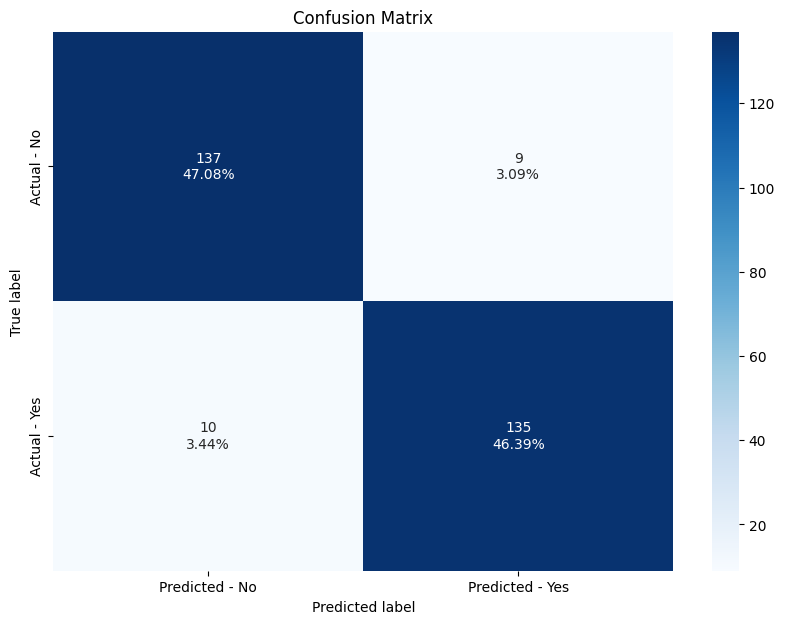

In [ ]:
# Evaluate Tuned Bagging Classifier Model

get_metrics_score(bagging_tuned, X_train, X_test, y_train, y_test)

make_confusion_matrix(bagging_tuned, X_test, y_test)

### Performance Comparison of Supervised Classification Models

In [ ]:
# Model Comparison: Collect Performance Metrics Across Models

# Identify the models to compare
models = [d_tree, dtree_tuned, rf_estimator, rf_tuned, bagging_classifier, bagging_tuned]

model_names = [
    "Decision Tree",
    "Tuned Decision Tree",
    "Random Forest",
    "Tuned Random Forest",
    "Bagging",
    "Tuned Bagging"
]

# Define empty lists to store results
acc_train, acc_test = [], []
recall_train, recall_test = [], []
precision_train, precision_test = [], []
f1_train, f1_test = [], []

# Loop through models and compute metrics
for model in models:
    scores = get_metrics_score(model, X_train, X_test, y_train, y_test, verbose=False)

    acc_train.append(scores[0])
    acc_test.append(scores[1])
    recall_train.append(scores[2])
    recall_test.append(scores[3])
    precision_train.append(scores[4])
    precision_test.append(scores[5])
    f1_train.append(scores[6])
    f1_test.append(scores[7])

In [ ]:
# Model Comparison Table

comparison_frame = pd.DataFrame({
    'Model': [
        'Decision Tree',
        'Tuned Decision Tree',
        'Random Forest',
        'Tuned Random Forest',
        'Bagging Classifier',
        'Tuned Bagging Classifier'
    ],
    'Train Accuracy': acc_train,
    'Test Accuracy': acc_test,
    'Train Recall': recall_train,
    'Test Recall': recall_test,
    'Train Precision': precision_train,
    'Test Precision': precision_test,
    'Train F1': f1_train,
    'Test F1': f1_test
})

# Sort models by Test Recall (descending)
comparison_frame = comparison_frame.sort_values(by='Test Recall', ascending=False)

comparison_frame.round(3)

,Model,Train Accuracy,Test Accuracy,Train Recall,Test Recall,Train Precision,Test Precision,Train F1,Test F1
1,Tuned Decision Tree,0.944,0.948,0.970,0.952,0.921,0.945,0.945,0.948
3,Tuned Random Forest,0.945,0.948,0.970,0.952,0.924,0.945,0.947,0.948
0,Decision Tree,1.000,0.931,1.000,0.931,1.000,0.931,1.000,0.931
2,Random Forest,1.000,0.918,1.000,0.931,1.000,0.906,1.000,0.918
5,Tuned Bagging Classifier,0.993,0.935,0.994,0.931,0.991,0.938,0.993,0.934
4,Bagging Classifier,0.990,0.921,0.985,0.903,0.994,0.936,0.990,0.919


#Feature Importance

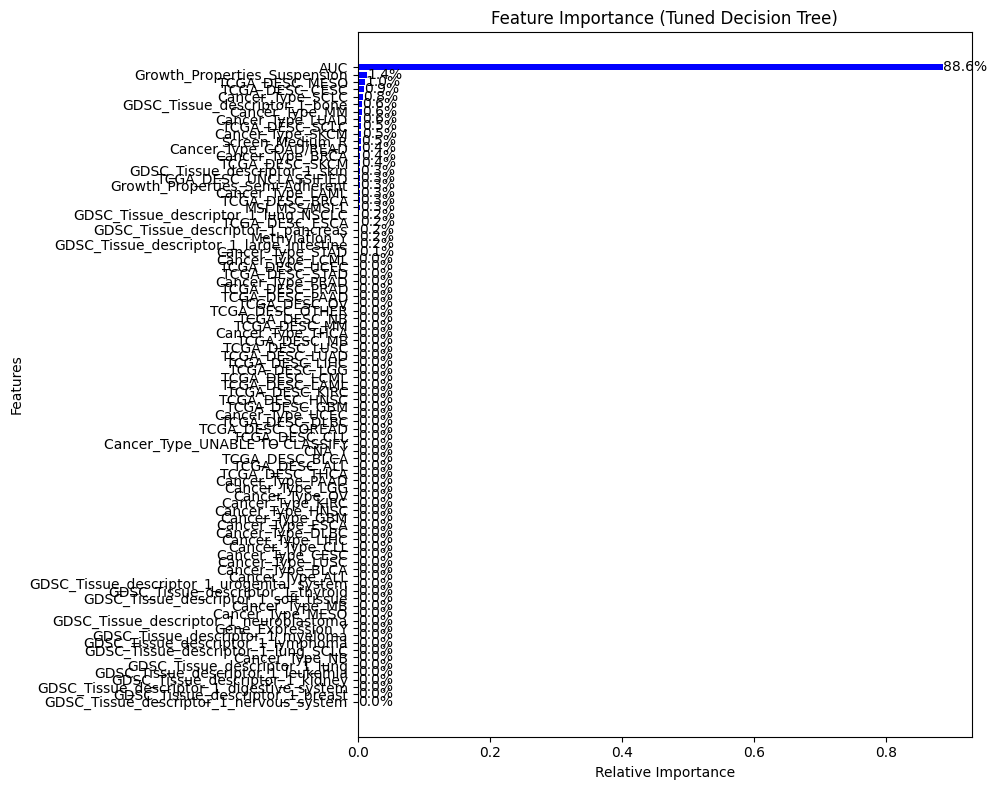

In [ ]:
# Feature Importance: Example - Tuned Decision Tree

feature_names = X_train.columns
importances = d_tree.feature_importances_ # Change if needed

# Sort in descending order
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 8))
plt.title('Feature Importance (Tuned Decision Tree)')

bars = plt.barh(range(len(indices)), importances[indices], color='blue', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])

plt.xlabel('Relative Importance')
plt.ylabel('Features')

# Show most important feature at the top
plt.gca().invert_yaxis()

# Add percentage labels
for i, v in enumerate(importances[indices]):
    plt.text(v + 0.001, i, f"{v*100:.1f}%", va='center')

plt.tight_layout()
plt.show()

In [ ]:
!jupyter nbconvert --to html /content/Cancer_Drug_ML_Classification.ipynb

[NbConvertApp] Converting notebook /content/Cancer_Drug_ML_Classification.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 18 image(s).
[NbConvertApp] Writing 3434493 bytes to /content/Cancer_Drug_ML_Classification.html
